In [1]:
import os
import sys
sys.path.append(os.path.abspath("/home/users/zhiyi/PROJECTS_ANALYSIS"))
os.environ['PROJ_LIB'] = '/home/users/zhiyi/.conda/envs/plot_musica/share/proj'

import cartopy.crs as ccrs
import matplotlib.patheffects as pe
import netCDF4 as nc
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib import pyplot as plt
from matplotlib.font_manager import FontProperties
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator, FuncFormatter

from zhiyi.plot.Plot_2D import Plot_2D


In [14]:
scrip_filename = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc"
base_dir = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.2_BB/atm/hist"
file_template = "MUSICA_production3.2_BB.cam.h3.{date_str}-00000.nc"
date_list = [f"2018-06-{day:02d}" for day in range(25, 31)]

FIG_SCALE = 1.35
FIGSIZE = (7.05 * FIG_SCALE, 4.15 * FIG_SCALE)
MAP_TICK_SIZE = 13.5
MAP_LABEL_SIZE = 7.0
MAP_PANEL_SIZE = 13
MAP_DATE_SIZE = 13
CBAR_TICK_SIZE = 15
CBAR_LABEL_SIZE = 14
TEXTBOX_PAD = 0.25

MAP_X_TICK_INTERVAL = 2
MAP_X_MINOR_TICK_VALUES = [-5, -3, -1, 1]
MAP_Y_TICK_INTERVAL = 2
MAP_X_TICK_LABEL_SIZE = MAP_TICK_SIZE
MAP_Y_TICK_LABEL_SIZE = MAP_TICK_SIZE
MAP_X_MAJOR_TICK_LENGTH = 3.2
MAP_X_MINOR_TICK_LENGTH = 1.8
MAP_Y_MAJOR_TICK_LENGTH = 3.2
MAP_Y_MINOR_TICK_LENGTH = 1.8
MAP_X_MAJOR_TICK_WIDTH = 0.8
MAP_X_MINOR_TICK_WIDTH = 0.7
MAP_Y_MAJOR_TICK_WIDTH = 0.8
MAP_Y_MINOR_TICK_WIDTH = 0.7
MAP_X_TICK_PAD = 2.5
MAP_Y_TICK_PAD = 2.5

PM25_CMIN = 0
PM25_CMAX = 20
PM25_CBAR_TICKS = np.arange(0, 21, 4)


In [23]:
def lon_formatter(x, pos=None):
    if x == 0:
        return "0°"
    if x > 0:
        return f"{x:.0f}°E"
    return f"{abs(x):.0f}°W"


def lat_formatter(y, pos=None):
    if y == 0:
        return "0°"
    if y > 0:
        return f"{y:.0f}°N"
    return f"{abs(y):.0f}°S"


def plot_figure_s15(pm25_fields, u_fields, v_fields, lon_scrip, lat_scrip, date_labels):
    fig = plt.figure(figsize=FIGSIZE)
    gs = GridSpec(
        2, 4,
        figure=fig,
        width_ratios=[1, 1, 1, 0.055],
        height_ratios=[1, 1],
        wspace=0.18,
        hspace=-0.2,
    )
    axes = [fig.add_subplot(gs[r, c], projection=ccrs.PlateCarree()) for r in range(2) for c in range(3)]
    cbar_ax = fig.add_axes([0.873, 0.24, 0.013, 0.50])

    lon_sm, lat_sm = -1.96000, 53.54200
    lon_w, lat_w = -2.55667, 53.62944
    lon_manchester, lat_manchester = -2.2426, 53.4808

    step = 35
    pm25_mappable = None
    for i, ax in enumerate(axes):
        p = Plot_2D(
            pm25_fields[i], scrip_file=scrip_filename, pretty_tick=True,
            lon_range=[-6, 2],
            lat_range=[50, 56],
            lon_interval=MAP_X_TICK_INTERVAL,
            lat_interval=MAP_Y_TICK_INTERVAL,
            resolution="10m",
            state=True, country=True, title="", unit="ppbv",
            cmin=PM25_CMIN, cmax=PM25_CMAX,
            title_size=MAP_LABEL_SIZE,
            label_size=MAP_LABEL_SIZE,
            feature_line_lw=0.45,
            shrink=0.8,
            unit_offset=[0.05, 0],
            pad=0.14,
            grid_line=False,
            lonlat_line=False,
            colorbar=False,
            ax=ax,
        )
        pm25_mappable = p.im

        fire_marker_size = 4
        city_marker_size = 4
        wh_marker = 'o' if i == 0 else 'h'
        ax.plot(lon_sm, lat_sm, marker='h', markersize=fire_marker_size, color='white',
                path_effects=[pe.withStroke(linewidth=3, foreground='black')],
                transform=ccrs.PlateCarree())
        ax.plot(lon_w, lat_w, marker=wh_marker, markersize=fire_marker_size, color='white',
                path_effects=[pe.withStroke(linewidth=3, foreground='black')],
                transform=ccrs.PlateCarree())
        ax.plot(lon_manchester, lat_manchester, marker='^', markersize=city_marker_size, color='blue',
                path_effects=[pe.withStroke(linewidth=2.2, foreground='white')],
                transform=ccrs.PlateCarree())

        if i == 0:
            city_labels = [
                ("SM", lon_sm, lat_sm, lon_sm - 0.2, lat_sm + 0.24),
                ("WH", lon_w, lat_w, lon_w - 0.75, lat_w + 0.24),
                ("Manchester", lon_manchester, lat_manchester, lon_manchester - 0.4, lat_manchester - 0.62),
            ]
            for label, lon_pt, lat_pt, lon_txt, lat_txt in city_labels:
                ax.annotate(
                    label,
                    xy=(lon_pt, lat_pt),
                    xytext=(lon_txt, lat_txt),
                    textcoords=ccrs.PlateCarree()._as_mpl_transform(ax),
                    fontsize=11,
                    weight='semibold',
                    color='black',
                    path_effects=[pe.withStroke(linewidth=2, foreground='white')],
                )

        q = ax.quiver(
            lon_scrip[::step], lat_scrip[::step],
            np.asarray(u_fields[i])[::step], np.asarray(v_fields[i])[::step],
            scale=90, color='k', width=0.003, alpha=0.8,
            headaxislength=5, headwidth=5, headlength=6,
            transform=ccrs.PlateCarree(),
        )
        if i in [2, 5]:
            ax.quiverkey(
                q, X=0.765, Y=1.05, U=10, label='10 m/s',
                labelpos='E', coordinates='axes',
                fontproperties=FontProperties(size=11, weight='bold'),
            )

        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.set_xticks([], minor=False)
        ax.set_xticks(np.asarray(MAP_X_MINOR_TICK_VALUES), minor=True)
        ax.xaxis.set_minor_formatter(FuncFormatter(lon_formatter))
        if i in [0, 3]:
            ax.yaxis.set_tick_params(labelleft=True, labelright=False)
            ax.tick_params(axis='y', which='major', labelsize=MAP_Y_TICK_LABEL_SIZE,
                           pad=MAP_Y_TICK_PAD, length=MAP_Y_MAJOR_TICK_LENGTH,
                           width=MAP_Y_MAJOR_TICK_WIDTH)
            ax.tick_params(axis='y', which='minor', length=MAP_Y_MINOR_TICK_LENGTH,
                           width=MAP_Y_MINOR_TICK_WIDTH)
        else:
            ax.yaxis.set_tick_params(which='both', labelleft=False, labelright=False,
                                     left=False, right=False)
            ax.tick_params(axis='y', which='minor', left=False, right=False)

        ax.tick_params(axis='x', which='major', bottom=False, top=False, labelbottom=False)
        ax.tick_params(axis='x', which='minor', labelsize=MAP_X_TICK_LABEL_SIZE,
                       pad=MAP_X_TICK_PAD, length=MAP_X_MINOR_TICK_LENGTH,
                       width=MAP_X_MINOR_TICK_WIDTH, bottom=True, top=False,
                       labelbottom=True)
        if i in [0, 1, 2]:
            ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter))

        ax.text(0.972, 0.96, date_labels[i], transform=ax.transAxes,
                fontsize=MAP_DATE_SIZE, va='top', ha='right',
                bbox=dict(facecolor='white', edgecolor='none',
                          boxstyle=f'square, pad={TEXTBOX_PAD}', alpha=1))
        ax.text(0.030, 0.96, f'({chr(ord("a") + i)})', transform=ax.transAxes,
                fontsize=MAP_PANEL_SIZE, va='top', ha='left', weight='bold',
                bbox=dict(facecolor='white', edgecolor='none',
                          boxstyle=f'square, pad={TEXTBOX_PAD}', alpha=1))

    cb = fig.colorbar(
        pm25_mappable,
        cax=cbar_ax,
        orientation='vertical',
        extend='both',
        ticks=PM25_CBAR_TICKS,
    )
    cb.ax.tick_params(labelsize=CBAR_TICK_SIZE, length=2.3, width=0.7, pad=1.5)
    cb.set_label('PM$_{2.5}$ (µg/m³)', fontsize=15, labelpad=5)
    cb.ax.yaxis.set_label_position('right')
    return fig, axes


(<Figure size 951.75x560.25 with 7 Axes>,
 [<GeoAxes: >,
  <GeoAxes: >,
  <GeoAxes: >,
  <GeoAxes: >,
  <GeoAxes: >,
  <GeoAxes: >])

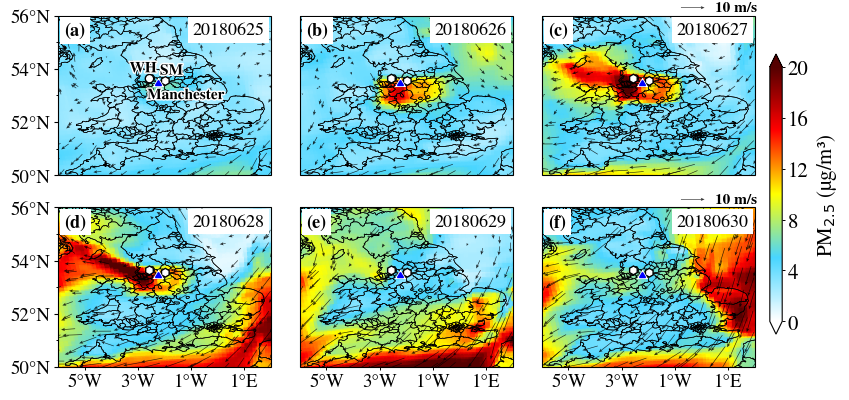

In [24]:
file_paths_BB = [
    f"{base_dir}/{file_template.format(date_str=date_str)}"
    for date_str in date_list
]
datasets_BB = [xr.open_dataset(fp) for fp in file_paths_BB]

pm25_surface = []
u_surface = []
v_surface = []
for ds in datasets_BB:
    pm25_surface.append(ds["PM25"].isel(time=0, lev=-1) * 1e9)
    if "time" in ds.dims:
        u_surface.append(ds["U"].isel(time=0, lev=-1).values)
        v_surface.append(ds["V"].isel(time=0, lev=-1).values)
    else:
        u_surface.append(ds["U"].isel(lev=-1).values)
        v_surface.append(ds["V"].isel(lev=-1).values)

with nc.Dataset(scrip_filename) as f:
    lon_scrip = f.variables['grid_center_lon'][:]
    lat_scrip = f.variables['grid_center_lat'][:]

date_labels = pd.to_datetime(date_list).strftime("%Y%m%d")
plot_figure_s15(pm25_surface, u_surface, v_surface, lon_scrip, lat_scrip, date_labels)


In [6]:
figure_data_dir = "/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data"
figure_s15_nc = os.path.join(figure_data_dir, "FigureS15.nc")
os.makedirs(figure_data_dir, exist_ok=True)

file_paths_BB = [
    f"{base_dir}/{file_template.format(date_str=date_str)}"
    for date_str in date_list
]
datasets_BB = [xr.open_dataset(fp) for fp in file_paths_BB]

pm25_surface = []
u_surface = []
v_surface = []
for ds in datasets_BB:
    pm25_surface.append(ds["PM25"].isel(time=0, lev=-1).values * 1e9)
    if "time" in ds.dims:
        u_surface.append(ds["U"].isel(time=0, lev=-1).values)
        v_surface.append(ds["V"].isel(time=0, lev=-1).values)
    else:
        u_surface.append(ds["U"].isel(lev=-1).values)
        v_surface.append(ds["V"].isel(lev=-1).values)

with nc.Dataset(scrip_filename) as f:
    lon_scrip = f.variables['grid_center_lon'][:]
    lat_scrip = f.variables['grid_center_lat'][:]

figure_s15_data = xr.Dataset(
    data_vars={
        "pm25_surface": (("date", "ncol"), np.asarray(pm25_surface)),
        "u_surface": (("date", "ncol"), np.asarray(u_surface)),
        "v_surface": (("date", "ncol"), np.asarray(v_surface)),
        "lon_scrip": (("ncol",), np.asarray(lon_scrip)),
        "lat_scrip": (("ncol",), np.asarray(lat_scrip)),
    },
    coords={
        "date": date_list,
    },
)
figure_s15_data.to_netcdf(figure_s15_nc)
for ds in datasets_BB:
    ds.close()
figure_s15_nc


'/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data/FigureS15.nc'

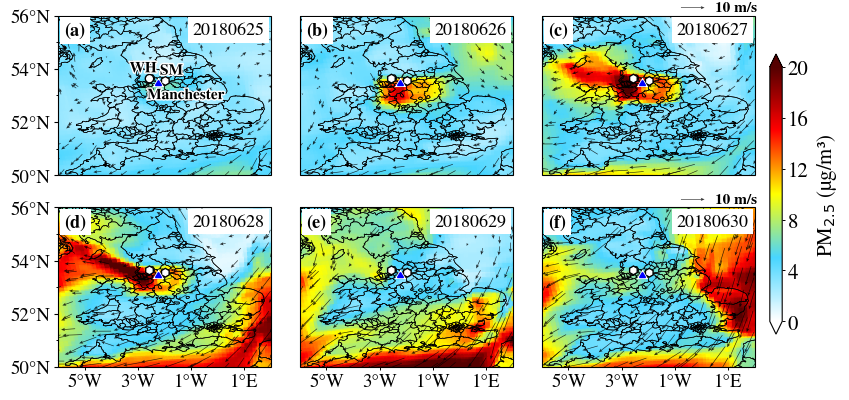

In [26]:
figure_s15_nc = "/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data/FigureS15.nc"
figure_s15_saved = xr.open_dataset(figure_s15_nc)
date_labels = pd.to_datetime(figure_s15_saved["date"].values).strftime("%Y%m%d")

pm25_surface_saved = [figure_s15_saved["pm25_surface"].isel(date=i) for i in range(figure_s15_saved.sizes["date"])]
u_surface_saved = [figure_s15_saved["u_surface"].isel(date=i).values for i in range(figure_s15_saved.sizes["date"])]
v_surface_saved = [figure_s15_saved["v_surface"].isel(date=i).values for i in range(figure_s15_saved.sizes["date"])]
lon_scrip_saved = figure_s15_saved["lon_scrip"].values
lat_scrip_saved = figure_s15_saved["lat_scrip"].values


def lon_formatter_saved(x, pos=None):
    if x == 0:
        return "0°"
    if x > 0:
        return f"{x:.0f}°E"
    return f"{abs(x):.0f}°W"


def lat_formatter_saved(y, pos=None):
    if y == 0:
        return "0°"
    if y > 0:
        return f"{y:.0f}°N"
    return f"{abs(y):.0f}°S"


fig = plt.figure(figsize=FIGSIZE)
gs = GridSpec(
    2, 4,
    figure=fig,
    width_ratios=[1, 1, 1, 0.055],
    height_ratios=[1, 1],
    wspace=0.18,
    hspace=-0.2,
)
axes = [fig.add_subplot(gs[r, c], projection=ccrs.PlateCarree()) for r in range(2) for c in range(3)]
cbar_ax = fig.add_axes([0.873, 0.24, 0.013, 0.50])


lon_sm, lat_sm = -1.96000, 53.54200
lon_w, lat_w = -2.55667, 53.62944
lon_manchester, lat_manchester = -2.2426, 53.4808

step = 35
pm25_mappable = None
for i, ax in enumerate(axes):
    p = Plot_2D(
        pm25_surface_saved[i], scrip_file=scrip_filename, pretty_tick=True,
        lon_range=[-6, 2],
        lat_range=[50, 56],
        lon_interval=MAP_X_TICK_INTERVAL,
        lat_interval=MAP_Y_TICK_INTERVAL,
        resolution="10m",
        state=True, country=True, title="", unit="ppbv",
        cmin=PM25_CMIN, cmax=PM25_CMAX,
        title_size=MAP_LABEL_SIZE,
        label_size=MAP_LABEL_SIZE,
        feature_line_lw=0.45,
        shrink=0.8,
        unit_offset=[0.05, 0],
        pad=0.14,
        grid_line=False,
        lonlat_line=False,
        colorbar=False,
        ax=ax,
    )
    pm25_mappable = p.im

    fire_marker_size = 4
    city_marker_size = 4
    wh_marker = 'o' if i == 0 else 'h'
    ax.plot(lon_sm, lat_sm, marker='h', markersize=fire_marker_size, color='white',
            path_effects=[pe.withStroke(linewidth=3, foreground='black')],
            transform=ccrs.PlateCarree())
    ax.plot(lon_w, lat_w, marker=wh_marker, markersize=fire_marker_size, color='white',
            path_effects=[pe.withStroke(linewidth=3, foreground='black')],
            transform=ccrs.PlateCarree())
    ax.plot(lon_manchester, lat_manchester, marker='^', markersize=city_marker_size, color='blue',
            path_effects=[pe.withStroke(linewidth=2.2, foreground='white')],
            transform=ccrs.PlateCarree())

    if i == 0:
        city_labels = [
            ("SM", lon_sm, lat_sm, lon_sm - 0.2, lat_sm + 0.24),
            ("WH", lon_w, lat_w, lon_w - 0.75, lat_w + 0.24),
            ("Manchester", lon_manchester, lat_manchester, lon_manchester - 0.4, lat_manchester - 0.62),
        ]
        for label, lon_pt, lat_pt, lon_txt, lat_txt in city_labels:
            ax.annotate(
                label,
                xy=(lon_pt, lat_pt),
                xytext=(lon_txt, lat_txt),
                textcoords=ccrs.PlateCarree()._as_mpl_transform(ax),
                fontsize=11,
                weight='semibold',
                color='black',
                path_effects=[pe.withStroke(linewidth=2, foreground='white')],
            )

    q = ax.quiver(
        lon_scrip_saved[::step], lat_scrip_saved[::step],
        np.asarray(u_surface_saved[i])[::step], np.asarray(v_surface_saved[i])[::step],
        scale=90, color='k', width=0.003, alpha=0.8,
        headaxislength=5, headwidth=5, headlength=6,
        transform=ccrs.PlateCarree(),
    )
    if i in [2, 5]:
        ax.quiverkey(
            q, X=0.765, Y=1.05, U=10, label='10 m/s',
            labelpos='E', coordinates='axes',
            fontproperties=FontProperties(size=11, weight='bold'),
        )

    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.set_xticks([], minor=False)
    ax.set_xticks(np.asarray(MAP_X_MINOR_TICK_VALUES), minor=True)
    ax.xaxis.set_minor_formatter(FuncFormatter(lon_formatter_saved))
    if i in [0, 3]:
        ax.yaxis.set_tick_params(labelleft=True, labelright=False)
        ax.tick_params(axis='y', which='major', labelsize=MAP_Y_TICK_LABEL_SIZE,
                       pad=MAP_Y_TICK_PAD, length=MAP_Y_MAJOR_TICK_LENGTH,
                       width=MAP_Y_MAJOR_TICK_WIDTH)
        ax.tick_params(axis='y', which='minor', length=MAP_Y_MINOR_TICK_LENGTH,
                       width=MAP_Y_MINOR_TICK_WIDTH)
    else:
        ax.yaxis.set_tick_params(which='both', labelleft=False, labelright=False,
                                 left=False, right=False)
        ax.tick_params(axis='y', which='minor', left=False, right=False)

    ax.tick_params(axis='x', which='major', bottom=False, top=False, labelbottom=False)
    ax.tick_params(axis='x', which='minor', labelsize=MAP_X_TICK_LABEL_SIZE,
                   pad=MAP_X_TICK_PAD, length=MAP_X_MINOR_TICK_LENGTH,
                   width=MAP_X_MINOR_TICK_WIDTH, bottom=True, top=False,
                   labelbottom=True)
    if i in [0, 1, 2]:
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter_saved))

    ax.text(0.972, 0.96, date_labels[i], transform=ax.transAxes,
            fontsize=MAP_DATE_SIZE, va='top', ha='right',
            bbox=dict(facecolor='white', edgecolor='none',
                      boxstyle=f'square, pad={TEXTBOX_PAD}', alpha=1))
    ax.text(0.030, 0.96, f'({chr(ord("a") + i)})', transform=ax.transAxes,
            fontsize=MAP_PANEL_SIZE, va='top', ha='left', weight='bold',
            bbox=dict(facecolor='white', edgecolor='none',
                      boxstyle=f'square, pad={TEXTBOX_PAD}', alpha=1))

cb = fig.colorbar(
    pm25_mappable,
    cax=cbar_ax,
    orientation='vertical',
    extend='both',
    ticks=PM25_CBAR_TICKS,
)
cb.ax.tick_params(labelsize=CBAR_TICK_SIZE, length=2.3, width=0.7, pad=1.5)
cb.set_label('PM$_{2.5}$ (µg/m³)', fontsize=15, labelpad=5)
cb.ax.yaxis.set_label_position('right')

from pathlib import Path

FIGURES_DIR = Path("/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RASTER_DPI = 300
png_path = FIGURES_DIR / "FigureS15.png"
pdf_path = FIGURES_DIR / "FigureS15.pdf"

fig.savefig(png_path, dpi=RASTER_DPI, bbox_inches="tight", facecolor="white")

img = plt.imread(png_path)
height_px, width_px = img.shape[:2]
pdf_fig = plt.figure(figsize=(width_px / RASTER_DPI, height_px / RASTER_DPI), dpi=RASTER_DPI)
pdf_ax = pdf_fig.add_axes([0, 0, 1, 1])
pdf_ax.imshow(img)
pdf_ax.axis("off")
pdf_fig.savefig(pdf_path, format="pdf", dpi=RASTER_DPI, bbox_inches=None, pad_inches=0, facecolor="white")
plt.close(pdf_fig)
